# Motor Current Monitor

Read and graph live `Present_Current` values from all 6 SO-101 servos via the Feetech STS3215 bus.

## What this notebook does

Connects to the SO-101 robot arm via `SO101Follower`, then runs two background threads:

- **Plot thread** — reads `Present_Load` and `Present_Position` from the `shoulder_pan` motor every 100 ms and updates a live plot. Load is scaled from ±1024 raw counts to ±100 using a log transform (`sign(x) · C · log(1 + |x|/10)`), so it can be compared directly against the joint angle in degrees on the same axis.
- **Movement thread** — moves `shoulder_pan` incrementally (1°/step, 50 ms delay) between ±15°, toggling direction based on the starting position.

Both threads share a `threading.Lock` to serialize serial port access. Each cell returns immediately so the JupyterLab kernel stays idle and widget updates reach the browser continuously.


**version: motor_currents_05.ipynb**

**Goal:** Investigate `Present_Current` from the servo — decode it correctly using sign-magnitude encoding and compare it against `Present_Load` to understand how well load tracks actual motor current.


In [1]:
import sys
print(sys.executable)

/home/aaron/Script/lerobot_2026/.venv/bin/python3

In [2]:
import time
import collections
import matplotlib.pyplot as plt

from lerobot.robots.so_follower import SO101FollowerConfig, SO101Follower

print("real")

real

In [9]:
try:
    print("Connected:", robot.is_connected)
except NameError:
    print("robot not defined yet")


Connected: False

In [10]:
PORT = "/dev/serial/by-id/usb-1a86_USB_Single_Serial_5AAF263835-if00"

cfg = SO101FollowerConfig(port=PORT, id="my_so101_follower")
robot = SO101Follower(cfg)
robot.connect()
print("Connected.")

Connected.

In [11]:
print("Connected:", robot.is_connected)


Connected: True

Running. To stop: stop_event.set()

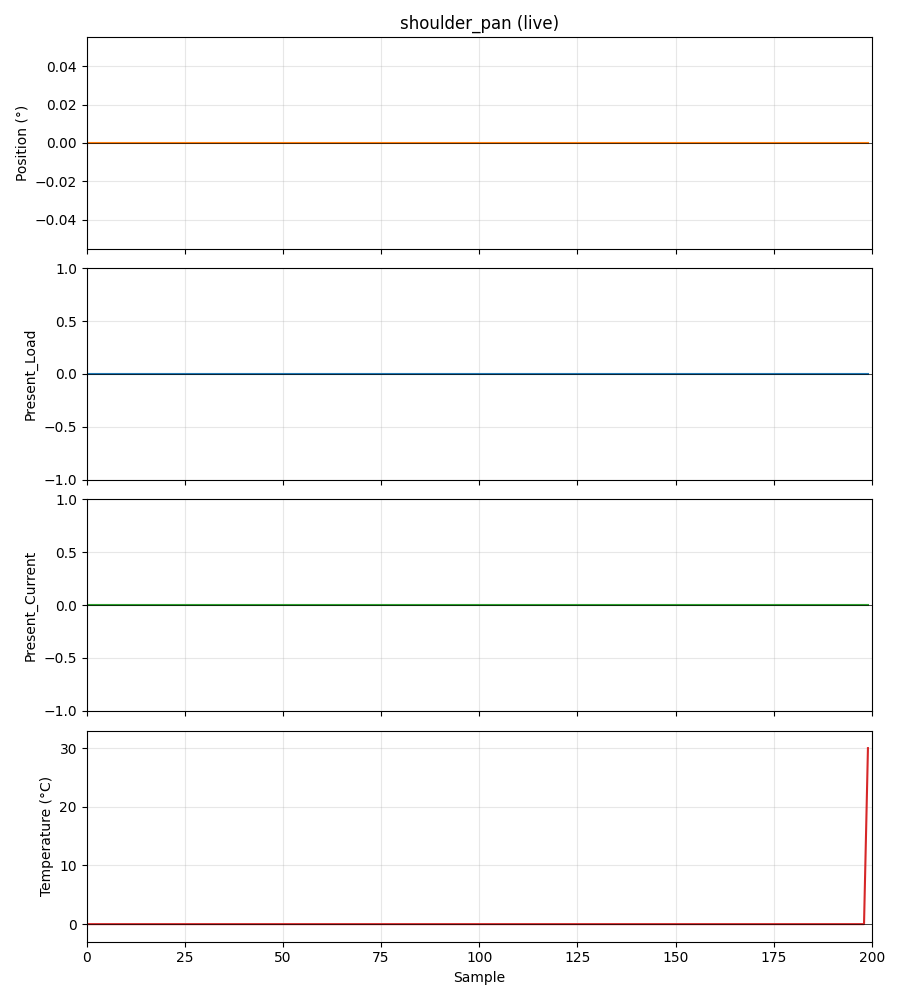

In [12]:
%matplotlib widget
import threading
import numpy as np

HISTORY = 200
INTERVAL_S = 0.1

load_history    = collections.deque([0] * HISTORY, maxlen=HISTORY)
pos_history     = collections.deque([0] * HISTORY, maxlen=HISTORY)
current_history = collections.deque([0] * HISTORY, maxlen=HISTORY)
temp_history    = collections.deque([0] * HISTORY, maxlen=HISTORY)

fig, (ax_pos, ax_load, ax_current, ax_temp) = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

line_pos,     = ax_pos.plot([0] * HISTORY, color="tab:orange")
line_load,    = ax_load.plot([0] * HISTORY, color="tab:blue")
line_current, = ax_current.plot([0] * HISTORY, color="tab:green")
line_temp,    = ax_temp.plot([0] * HISTORY, color="tab:red")

ax_pos.set_ylabel("Position (°)")
ax_pos.set_title("shoulder_pan (live)")
ax_load.set_ylabel("Present_Load")
ax_current.set_ylabel("Present_Current")
ax_temp.set_ylabel("Temperature (°C)")
ax_temp.set_xlabel("Sample")

for ax in (ax_pos, ax_load, ax_current, ax_temp):
    ax.set_xlim(0, HISTORY)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

stop_event = threading.Event()
bus_lock = threading.Lock()

def _plot_loop():
    while not stop_event.is_set():
        with bus_lock:
            loads       = robot.bus.sync_read("Present_Load")
            positions   = robot.bus.sync_read("Present_Position")
            currents    = robot.bus.sync_read("Present_Current")
            temps       = robot.bus.sync_read("Present_Temperature")
        pos_history.append(positions["shoulder_pan"])
        load_history.append(loads["shoulder_pan"])
        current_history.append(currents["shoulder_pan"])
        temp_history.append(temps["shoulder_pan"])
        line_pos.set_ydata(list(pos_history))
        line_load.set_ydata(list(load_history))
        line_current.set_ydata(list(current_history))
        line_temp.set_ydata(list(temp_history))
        # Auto-scale all axes
        for ax, hist in ((ax_pos, pos_history), (ax_load, load_history), (ax_current, current_history), (ax_temp, temp_history)):
            lo, hi = min(hist), max(hist)
            margin = max(1, (hi - lo) * 0.1)
            ax.set_ylim(lo - margin, hi + margin)
        fig.canvas.draw_idle()
        time.sleep(INTERVAL_S)

_plot_thread = threading.Thread(target=_plot_loop, daemon=True)
_plot_thread.start()
print("Running. To stop: stop_event.set()")


In [13]:
# Capture a safe baseline for all joints once — only shoulder_pan will ever be modified.
# This means a corrupted observation can never send other joints to garbage positions.
with bus_lock:
    _baseline = dict(robot.get_observation())

PAN_MIN, PAN_MAX = -30.0, 30.0

def _do_movement():
    goal = dict(_baseline)
    while not stop_event.is_set():
        with bus_lock:
            obs = robot.get_observation()
        current_pos = obs["shoulder_pan.pos"]

        # Sanity check: reject obviously corrupt readings
        if not (-180.0 <= current_pos <= 180.0):
            print(f"WARNING: Suspicious shoulder_pan reading ({current_pos:.1f}°), skipping")
            time.sleep(0.1)
            continue

        target = PAN_MAX if current_pos < 0 else PAN_MIN
        step = 1.0 if target > current_pos else -1.0
        steps = round(abs(target - current_pos))

        for _ in range(steps):
            if stop_event.is_set():
                break
            goal["shoulder_pan.pos"] += step
            # Hard clamp — never command outside the intended range
            goal["shoulder_pan.pos"] = max(PAN_MIN, min(PAN_MAX, goal["shoulder_pan.pos"]))
            with bus_lock:
                robot.send_action(goal)
            time.sleep(0.05)

        # Pause at each end before reversing direction
        stop_event.wait(timeout=1.5)

    print("Movement stopped.")

_move_thread = threading.Thread(target=_do_movement, daemon=True)
_move_thread.start()


In [ ]:
# Run this cell to disconnect cleanly when done
stop_event.set()
_plot_thread.join()
robot.disconnect()
print("Disconnected.")

In [16]:
# Diagnostic check — run after any unexpected movement to verify all motors are healthy
import threading as _threading
_diag_lock = bus_lock if "bus_lock" in dir() else _threading.Lock()

with _diag_lock:
    positions = robot.bus.sync_read("Present_Position")
    temps = robot.bus.sync_read("Present_Temperature")
    statuses = robot.bus.sync_read("Status")

for name in robot.bus.motors:
    print(f"{name:15s}  pos={positions[name]:7.1f}°  temp={temps[name]}°C  status={statuses[name]}")


shoulder_pan     pos=  -36.0°  temp=30°C  status=0
shoulder_lift    pos=  -81.3°  temp=23°C  status=0
elbow_flex       pos=   80.0°  temp=23°C  status=0
wrist_flex       pos=   54.0°  temp=24°C  status=0
wrist_roll       pos=    0.5°  temp=30°C  status=0
gripper          pos=   23.0°  temp=30°C  status=0